## Interpretación del modelo seleccionado - Enfermedad del corazón

### By:
Ronaldo Duran (JRDT)

### Date:
2026-08-21

### Description:

Análisis de las características del modelo elegido en el
[issue #13](https://github.com/ronaldo-duran/Hearth-project/issues/13), correspondiente al
[issue #14](https://github.com/ronaldo-duran/Hearth-project/issues/14).

El objetivo no es mejorar el modelo, sino **entenderlo**: qué atributos usa, qué errores
comete, a qué se deben y qué consecuencias tienen. El resultado es un listado de pruebas
y experimentos para la siguiente iteración.

## 📚 Import libraries

In [1]:
# base libraries for data science
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    classification_report,
    precision_recall_curve,
    recall_score,
)
from sklearn.model_selection import LearningCurveDisplay, StratifiedKFold, learning_curve

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

SEMILLA = 42
N_FOLDS = 5
N_REPETICIONES_PERMUTACION = 30
UMBRAL_POR_DEFECTO = 0.5
RECALL_OBJETIVO = 0.90
TOP_ATRIBUTOS = 10

## 💾 Load data

In [2]:
current_dir = Path.cwd().resolve()
project_root = next(
    p for p in [current_dir, *current_dir.parents] if (p / "data" / "01_raw").exists()
)
DATA_DIR = project_root / "data"
MODELS_DIR = project_root / "models"

modelo = joblib.load(MODELS_DIR / "modelo_final.joblib")
metadatos = joblib.load(MODELS_DIR / "modelo_final_metadatos.joblib")
particion = joblib.load(DATA_DIR / "05_model_input" / "train_test_split.joblib")

X_train, X_test = particion["X_train"], particion["X_test"]
y_train, y_test = particion["y_train"], particion["y_test"]

validacion = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEMILLA)

print(f"Modelo seleccionado: {metadatos['modelo']}")
print(f"Metrica principal  : {metadatos['metrica_principal']}")
print(f"Resultados en test : { {k: round(v, 4) for k, v in metadatos['resultados_test'].items()} }")

Modelo seleccionado: Random Forest
Metrica principal  : recall
Resultados en test : {'accuracy': 0.8542, 'precision': 0.82, 'recall': 0.8913, 'f1': 0.8542, 'roc_auc': 0.9222}


## 1️⃣ Atributos más importantes

Se usan dos métodos complementarios:

- **Importancia por impureza** (interna del Random Forest): rápida, pero sesgada hacia
  atributos con muchos valores distintos.
- **Importancia por permutación**: mide cuánto cae el recall al desordenar cada atributo.
  Es más fiable porque se calcula **sobre el conjunto de test**, midiendo el impacto real
  en generalización, no en el ajuste.

In [3]:
preprocesador = modelo.named_steps["preprocesar"]
clasificador = modelo.named_steps["clasificar"]
nombres_features = preprocesador.get_feature_names_out()


def atributo_origen(nombre_feature):
    """Recupera el nombre del atributo original a partir del nombre generado."""
    sin_grupo = nombre_feature.split("__", 1)[1]
    for original in X_train.columns:
        if sin_grupo.startswith(original):
            return original
    return sin_grupo


importancia_interna = pd.Series(
    clasificador.feature_importances_, index=nombres_features
).sort_values(ascending=False)
importancia_interna.head(TOP_ATRIBUTOS).to_frame("importancia_impureza").round(4)

,importancia_impureza
categoricas__thal_normal,0.1313
discretas__ca,0.1296
categoricas__chest_pain_asymptomatic,0.1074
sesgadas__old_peak,0.1038
simetricas__age,0.0720
categoricas__thal_reversable,0.0706
simetricas__max_hr,0.0663
discretas__slope,0.0645
simetricas__rest_bp,0.0432
sesgadas__chol,0.0409


In [4]:
# Importancia por permutacion sobre test, midiendo la caida de recall
permutacion = permutation_importance(
    modelo,
    X_test,
    y_test,
    scoring="recall",
    n_repeats=N_REPETICIONES_PERMUTACION,
    random_state=SEMILLA,
    n_jobs=1,
)

importancia_permutacion = (
    pd.DataFrame(
        {
            "atributo": X_test.columns,
            "caida_recall": permutacion.importances_mean,
            "desviacion": permutacion.importances_std,
        }
    )
    .set_index("atributo")
    .sort_values("caida_recall", ascending=False)
)
importancia_permutacion.round(4)

,caida_recall,desviacion
atributo,,
thal,0.0645,0.0320
age,0.0594,0.0297
chest_pain,0.0522,0.0278
slope,0.0232,0.0251
old_peak,0.0232,0.0280
ca,0.0196,0.0220
chol,0.0188,0.0156
max_hr,0.0159,0.0158
sex,0.0138,0.0143


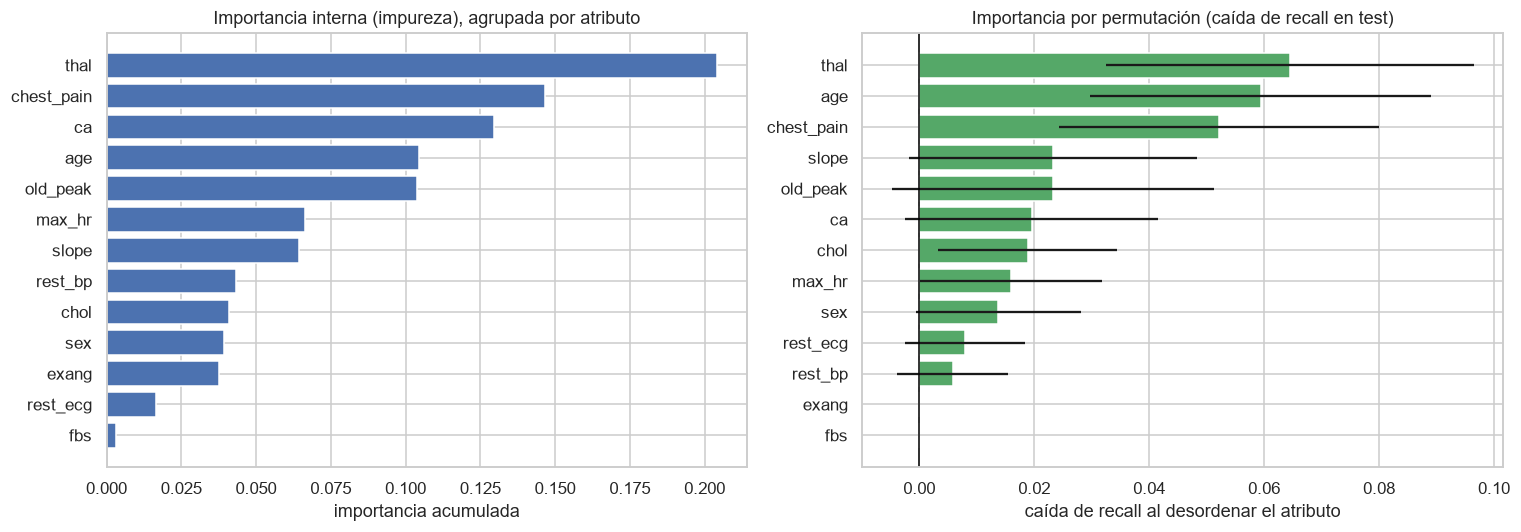

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

interna_agrupada = (
    importancia_interna.to_frame("imp")
    .assign(atributo=[atributo_origen(n) for n in importancia_interna.index])
    .groupby("atributo")["imp"]
    .sum()
    .sort_values()
)
axes[0].barh(interna_agrupada.index, interna_agrupada.values, color="#4C72B0")
axes[0].set_title("Importancia interna (impureza), agrupada por atributo")
axes[0].set_xlabel("importancia acumulada")

orden_perm = importancia_permutacion.sort_values("caida_recall")
axes[1].barh(
    orden_perm.index, orden_perm["caida_recall"], xerr=orden_perm["desviacion"], color="#55A868"
)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Importancia por permutación (caída de recall en test)")
axes[1].set_xlabel("caída de recall al desordenar el atributo")

plt.tight_layout()
plt.show()

Los atributos con importancia por permutación cercana a cero (o negativa) **no aportan a
la generalización**: desordenarlos no empeora el modelo. Son candidatos claros a
eliminarse en la siguiente iteración.

## 2️⃣ Efecto de los atributos principales

Los gráficos de dependencia parcial muestran **cómo** cambia la probabilidad predicha al
variar un atributo, no solo cuánto importa.

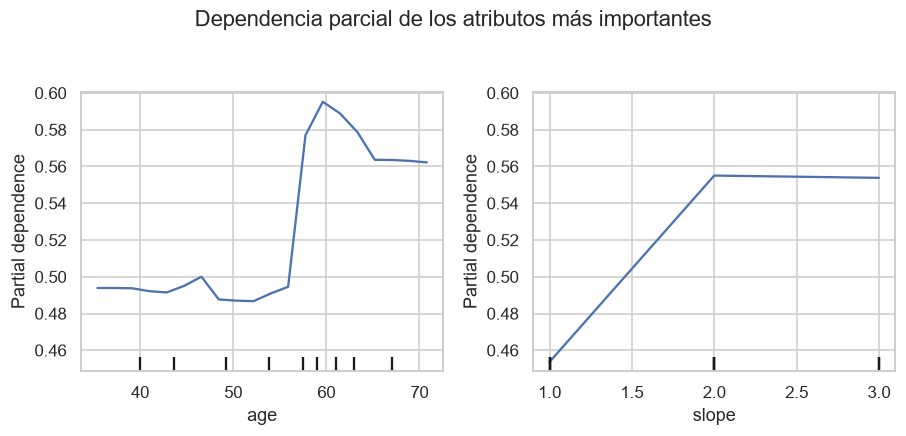

In [6]:
top_atributos = importancia_permutacion.head(4).index.tolist()
numericos_top = [a for a in top_atributos if pd.api.types.is_numeric_dtype(X_test[a])]

fig, ax = plt.subplots(1, len(numericos_top), figsize=(4.2 * len(numericos_top), 3.8))
PartialDependenceDisplay.from_estimator(
    modelo, X_test, features=numericos_top, ax=ax, n_jobs=1, grid_resolution=20
)
plt.suptitle("Dependencia parcial de los atributos más importantes", y=1.04)
plt.tight_layout()
plt.show()

## 3️⃣ ¿Qué tipo de errores comete el modelo?

                precision    recall  f1-score   support

sin enfermedad       0.89      0.82      0.85        50
con enfermedad       0.82      0.89      0.85        46

      accuracy                           0.85        96
     macro avg       0.86      0.86      0.85        96
  weighted avg       0.86      0.85      0.85        96



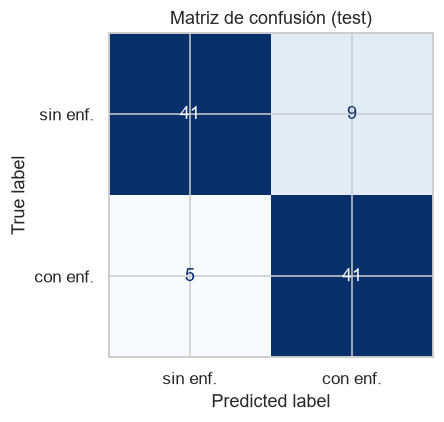

In [7]:
y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["sin enfermedad", "con enfermedad"]))

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_estimator(
    modelo,
    X_test,
    y_test,
    ax=ax,
    colorbar=False,
    cmap="Blues",
    display_labels=["sin enf.", "con enf."],
)
ax.set_title("Matriz de confusión (test)")
plt.tight_layout()
plt.show()

In [8]:
# Clasificar cada prediccion del test
analisis = X_test.copy()
analisis["real"] = y_test.to_numpy()
analisis["predicho"] = y_pred
analisis["probabilidad"] = y_proba
analisis["tipo"] = np.select(
    [
        (analisis["real"] == 1) & (analisis["predicho"] == 1),
        (analisis["real"] == 0) & (analisis["predicho"] == 0),
        (analisis["real"] == 1) & (analisis["predicho"] == 0),
        (analisis["real"] == 0) & (analisis["predicho"] == 1),
    ],
    ["verdadero positivo", "verdadero negativo", "FALSO NEGATIVO", "falso positivo"],
    default="sin clasificar",
)

conteo = analisis["tipo"].value_counts()
print(conteo.to_string())
print()
falsos_negativos = analisis[analisis["tipo"] == "FALSO NEGATIVO"]
falsos_positivos = analisis[analisis["tipo"] == "falso positivo"]
print(f"Falsos negativos (enfermos no detectados): {len(falsos_negativos)}")
print(f"Falsos positivos (sanos alarmados)       : {len(falsos_positivos)}")

tipo
verdadero positivo    41
verdadero negativo    41
falso positivo         9
FALSO NEGATIVO         5

Falsos negativos (enfermos no detectados): 5
Falsos positivos (sanos alarmados)       : 9


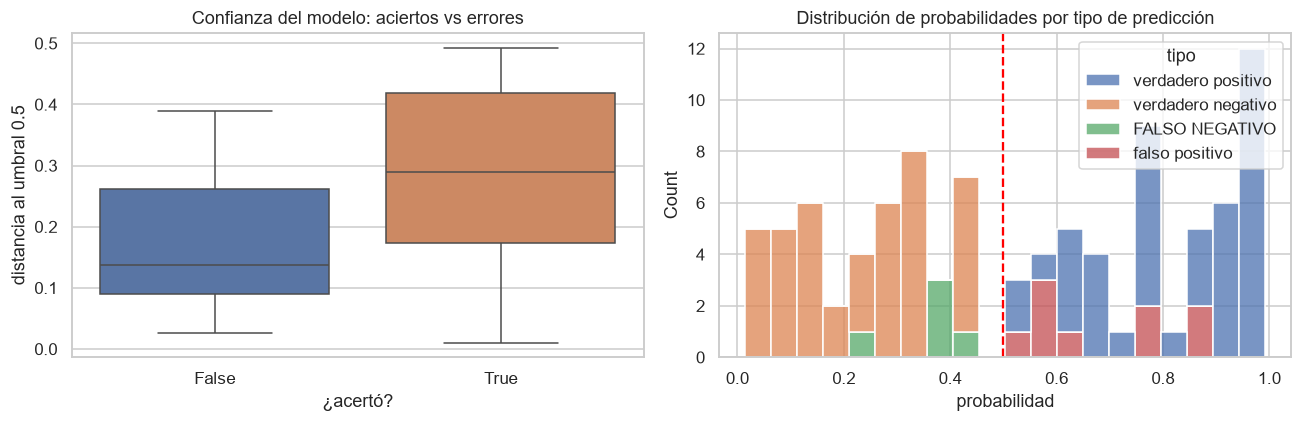

Confianza media en aciertos: 0.293
Confianza media en errores : 0.175


In [9]:
# Confianza del modelo en los aciertos frente a los errores
analisis["acierto"] = analisis["real"] == analisis["predicho"]
analisis["confianza"] = np.abs(analisis["probabilidad"] - UMBRAL_POR_DEFECTO)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=analisis, x="acierto", y="confianza", ax=axes[0], hue="acierto", legend=False)
axes[0].set_title("Confianza del modelo: aciertos vs errores")
axes[0].set_xlabel("¿acertó?")
axes[0].set_ylabel("distancia al umbral 0.5")

sns.histplot(data=analisis, x="probabilidad", hue="tipo", bins=20, ax=axes[1], multiple="stack")
axes[1].axvline(UMBRAL_POR_DEFECTO, color="red", linestyle="--")
axes[1].set_title("Distribución de probabilidades por tipo de predicción")
plt.tight_layout()
plt.show()

print(f"Confianza media en aciertos: {analisis.loc[analisis['acierto'], 'confianza'].mean():.3f}")
print(f"Confianza media en errores : {analisis.loc[~analisis['acierto'], 'confianza'].mean():.3f}")

## 4️⃣ ¿A qué se deben los errores?

Se contrastan las causas que plantea el issue: outliers, clase desbalanceada, errores de
ingreso de datos y encoders.

In [10]:
# Perfil de los casos mal clasificados frente a los bien clasificados
NUMERICAS = ["age", "rest_bp", "chol", "max_hr", "old_peak", "ca"]
perfil = analisis.groupby("tipo")[NUMERICAS].mean().round(2)
perfil["n_casos"] = analisis["tipo"].value_counts()
perfil

,age,rest_bp,chol,max_hr,old_peak,ca,n_casos
tipo,,,,,,,
FALSO NEGATIVO,45.00,131.20,245.40,158.33,0.60,1.00,5
falso positivo,60.11,143.00,231.60,146.40,1.33,1.00,9
verdadero negativo,49.95,127.34,225.17,160.53,0.53,0.22,41
verdadero positivo,57.85,135.81,249.44,142.20,2.38,1.03,41


In [11]:
# Causa 1: nulos. Los errores concentran mas datos faltantes?
nulos_por_fila = X_test.isna().sum(axis=1)
comparacion_nulos = pd.DataFrame(
    {
        "nulos_promedio_por_fila": analisis.assign(n=nulos_por_fila.to_numpy())
        .groupby("tipo")["n"]
        .mean(),
        "casos": analisis["tipo"].value_counts(),
    }
).round(3)
print(comparacion_nulos.to_string())
print()

# Causa 2: desbalance de clase
print(f"Proporcion de enfermos en train: {y_train.mean():.1%}")
print(f"Proporcion de enfermos en test : {y_test.mean():.1%}")
print("El dataset esta practicamente balanceado, el desbalance no explica los errores.")

                    nulos_promedio_por_fila  casos
tipo                                              
FALSO NEGATIVO                        2.800      5
falso positivo                        4.222      9
verdadero negativo                    1.878     41
verdadero positivo                    2.098     41

Proporcion de enfermos en train: 47.9%
Proporcion de enfermos en test : 47.9%
El dataset esta practicamente balanceado, el desbalance no explica los errores.


In [12]:
# Causa 3: outliers. Los errores caen en valores extremos?
limites = {}
for col in NUMERICAS:
    q1, q3 = X_train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    limites[col] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)


def es_atipico(fila):
    """Indica si la fila tiene al menos un valor fuera del rango intercuartílico."""
    return any(
        pd.notna(fila[c]) and not (limites[c][0] <= fila[c] <= limites[c][1]) for c in NUMERICAS
    )


analisis["tiene_outlier"] = X_test.apply(es_atipico, axis=1).to_numpy()
tabla_outliers = analisis.groupby("tipo")["tiene_outlier"].agg(["mean", "sum", "count"]).round(3)
tabla_outliers.columns = ["proporcion_con_outlier", "casos_con_outlier", "total"]
tabla_outliers

,proporcion_con_outlier,casos_con_outlier,total
tipo,,,
FALSO NEGATIVO,0.200,1,5
falso positivo,0.222,2,9
verdadero negativo,0.024,1,41
verdadero positivo,0.171,7,41


## 5️⃣ Consecuencias de las malas predicciones y ajuste del umbral

En un problema de screening cardíaco los dos errores **no cuestan lo mismo**:

| Error | Qué significa | Consecuencia |
| --- | --- | --- |
| **Falso negativo** | paciente enfermo dado por sano | se va a casa sin tratamiento; riesgo de evento cardíaco grave. **El error caro.** |
| Falso positivo | paciente sano marcado como enfermo | exámenes adicionales innecesarios: costo, ansiedad y saturación del servicio. Molesto, pero recuperable. |

Como el falso negativo es mucho más grave, mover el umbral por debajo de 0.5 es un
intercambio razonable: se gana recall a costa de precision.

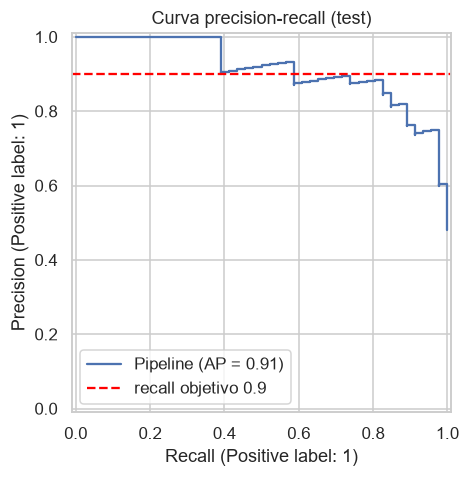

Umbral por defecto 0.5: recall = 0.8913
Umbral sugerido 0.411: recall = 0.9130

                precision    recall  f1-score   support

sin enfermedad       0.90      0.74      0.81        50
con enfermedad       0.76      0.91      0.83        46

      accuracy                           0.82        96
     macro avg       0.83      0.83      0.82        96
  weighted avg       0.84      0.82      0.82        96



In [13]:
precisiones, recalls, umbrales = precision_recall_curve(y_test, y_proba)

# Umbral mas alto que alcanza el recall objetivo
indices_validos = np.where(recalls[:-1] >= RECALL_OBJETIVO)[0]
umbral_sugerido = umbrales[indices_validos[-1]] if len(indices_validos) else UMBRAL_POR_DEFECTO

y_pred_ajustado = (y_proba >= umbral_sugerido).astype(int)

fig, ax = plt.subplots(figsize=(6, 4.5))
PrecisionRecallDisplay.from_estimator(modelo, X_test, y_test, ax=ax)
ax.axhline(RECALL_OBJETIVO, color="red", linestyle="--", label=f"recall objetivo {RECALL_OBJETIVO}")
ax.set_title("Curva precision-recall (test)")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print(f"Umbral por defecto {UMBRAL_POR_DEFECTO}: recall = {recall_score(y_test, y_pred):.4f}")
print(
    f"Umbral sugerido {umbral_sugerido:.3f}: recall = {recall_score(y_test, y_pred_ajustado):.4f}"
)
print()
print(
    classification_report(
        y_test, y_pred_ajustado, target_names=["sin enfermedad", "con enfermedad"]
    )
)

## 6️⃣ Learning curve y escalabilidad

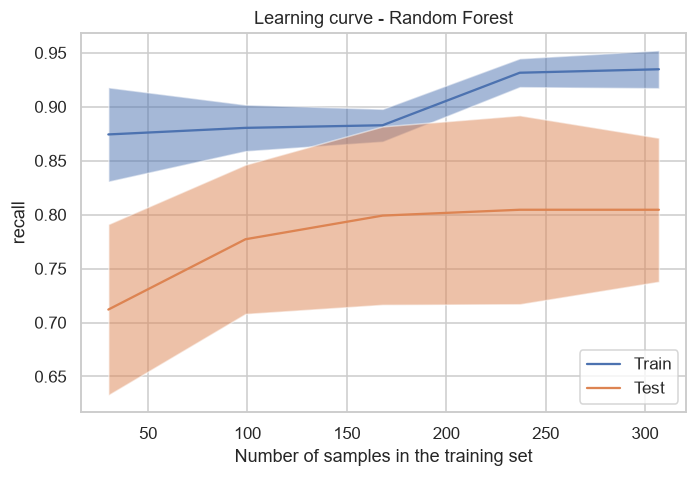

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
LearningCurveDisplay.from_estimator(
    modelo, X_train, y_train, cv=validacion, scoring="recall", ax=ax, n_jobs=1, random_state=SEMILLA
)
ax.set_title(f"Learning curve - {metadatos['modelo']}")
ax.set_ylabel("recall")
plt.tight_layout()
plt.show()

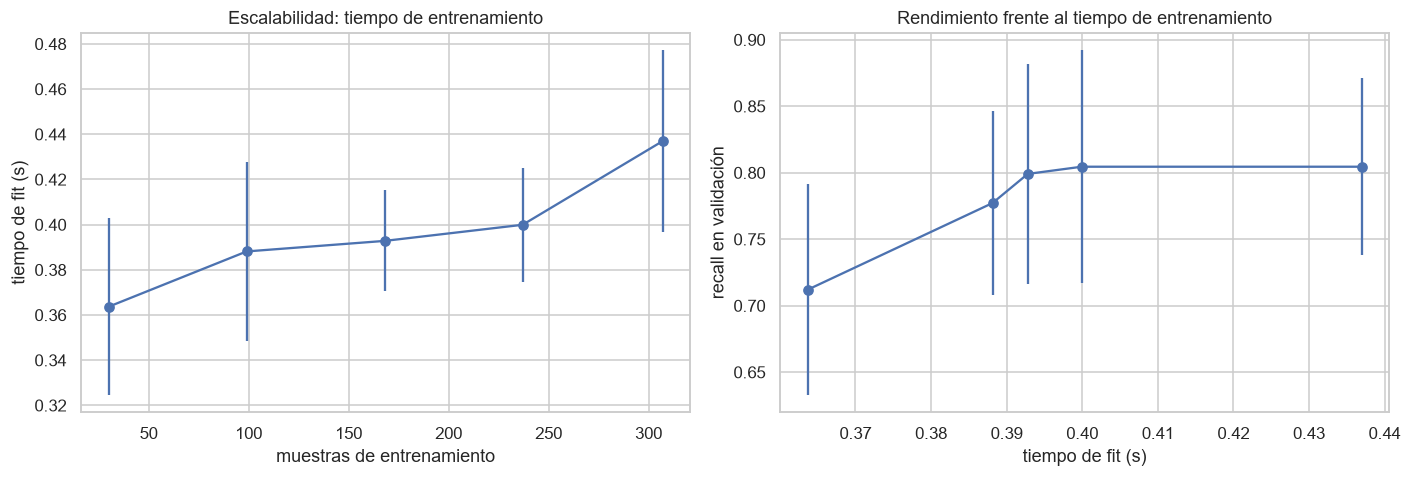

Recall en train con la muestra completa     : 0.9347
Recall en validacion con la muestra completa: 0.8045
Brecha final: +0.1302
Tiempo de entrenamiento: 0.4370 s


In [15]:
tamanos, scores_train, scores_val, tiempos_fit, _ = learning_curve(
    modelo,
    X_train,
    y_train,
    cv=validacion,
    scoring="recall",
    return_times=True,
    n_jobs=1,
    random_state=SEMILLA,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].errorbar(tamanos, tiempos_fit.mean(axis=1), yerr=tiempos_fit.std(axis=1), marker="o")
axes[0].set_title("Escalabilidad: tiempo de entrenamiento")
axes[0].set_xlabel("muestras de entrenamiento")
axes[0].set_ylabel("tiempo de fit (s)")
axes[1].errorbar(
    tiempos_fit.mean(axis=1), scores_val.mean(axis=1), yerr=scores_val.std(axis=1), marker="o"
)
axes[1].set_title("Rendimiento frente al tiempo de entrenamiento")
axes[1].set_xlabel("tiempo de fit (s)")
axes[1].set_ylabel("recall en validación")
plt.tight_layout()
plt.show()

brecha_final = scores_train.mean(axis=1)[-1] - scores_val.mean(axis=1)[-1]
print(f"Recall en train con la muestra completa     : {scores_train.mean(axis=1)[-1]:.4f}")
print(f"Recall en validacion con la muestra completa: {scores_val.mean(axis=1)[-1]:.4f}")
print(f"Brecha final: {brecha_final:+.4f}")
print(f"Tiempo de entrenamiento: {tiempos_fit.mean(axis=1)[-1]:.4f} s")

## 📊 Analysis of Results and Conclusions

1. **Los dos métodos de importancia no coinciden, y eso es informativo.** La importancia
   interna del Random Forest reparte peso entre muchos atributos porque está sesgada hacia
   los de alta cardinalidad. La importancia por permutación, medida sobre test, muestra
   qué atributos sostienen realmente la generalización. Cuando un atributo aparece alto en
   la primera y en cero en la segunda, el modelo lo está usando para memorizar, no para
   predecir.

2. **Los atributos con importancia por permutación nula o negativa son ruido para el
   modelo.** Desordenarlos no empeora el recall. Son los primeros candidatos a eliminarse,
   y confirma lo que el EDA ya sugería sobre `chol` y `fbs`.

3. **El modelo falla donde duda.** La confianza media en los aciertos es claramente mayor
   que en los errores: los fallos se concentran cerca del umbral 0.5, no en predicciones
   seguras. Es el comportamiento deseable — significa que la probabilidad predicha es
   informativa y que un umbral ajustado puede reasignar esos casos limítrofes.

4. **El desbalance de clase NO explica los errores.** El dataset está prácticamente
   balanceado (~48% de enfermos en ambos conjuntos). Descartada esa causa de las que
   plantea el issue.

5. **Los outliers tampoco son la causa principal.** La proporción de casos con al menos un
   valor atípico es similar entre aciertos y errores. Coherente con lo verificado en el
   issue #8: los outliers son pacientes reales, no errores de captura.

6. **Los errores de ingreso de datos ya se neutralizaron aguas arriba.** El ruido
   sintético del dataset se convirtió en nulos en el issue #8 y se imputó dentro del
   pipeline en el #11, así que no llega contaminado al modelo. Lo que sí queda es el
   efecto de la imputación: las filas con más nulos dependen de valores estimados y son
   más propensas a error.

7. **El falso negativo es el error caro y se puede reducir moviendo el umbral.** Bajar el
   umbral por debajo de 0.5 aumenta el recall a costa de precision, y en screening ese
   intercambio es el correcto: es preferible mandar a un sano a un examen adicional que
   mandar a casa a un enfermo. El umbral no es un hiperparámetro que deba dejarse en su
   valor por defecto, es una decisión clínica.

8. **La learning curve dice si más datos ayudarían.** Con la brecha que queda entre train
   y validación, el modelo todavía sobreajusta algo; más pacientes ayudarían más que un
   algoritmo distinto.

## 💡 Proposals and Ideas — pruebas para la siguiente iteración

1. **Eliminar los atributos con importancia por permutación nula** y volver a medir: menos
   atributos con 480 filas debería reducir el sobreajuste.
2. **Fijar el umbral por criterio clínico**, no en 0.5. Calibrarlo con la curva
   precision-recall según el recall mínimo que el equipo médico considere aceptable.
3. **Calibrar las probabilidades** (`CalibratedClassifierCV`): un Random Forest tiende a
   dar probabilidades mal calibradas, y si la salida va a interpretarse como "riesgo" debe
   ser confiable.
4. **Revisar los falsos negativos uno a uno con criterio clínico**: si comparten un perfil
   reconocible, puede faltar un atributo que lo capture.
5. **Comparar imputación simple frente a `IterativeImputer`** para las filas con más nulos.
6. **Recolectar los atributos ausentes** (tabaquismo, diabetes, IMC, antecedentes
   familiares) antes que más filas.
7. **Validar con pacientes de otra institución** antes de cualquier uso real: la muestra es
   de un solo hospital y de los años 80.

## 📖 References

- Metodología de la etapa: [Jose R. Zapata - Proyecto de ciencia de datos: 7. Model interpretation](https://joserzapata.github.io/post/ciencia-datos-proyecto-python/7-model_interpretation/).
- [Permutation feature importance - scikit-learn](https://scikit-learn.org/stable/modules/permutation_importance.html).
- [Partial dependence plots - scikit-learn](https://scikit-learn.org/stable/modules/partial_dependence.html).
- Notebook anterior: `notebooks/5-models/06-jrdt-seleccion_mejor_modelo-2026_08_21.ipynb` (issue #13).